In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
df = pd.read_csv("../data/loan_approval_dataset.csv")
df.columns = df.columns.str.strip()

X = df.drop(columns=["loan_id", "loan_status"])
y = df["loan_status"]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

for col in categorical_cols:
    X[col] = X[col].str.strip()

y = y.str.strip()

X_encoded = X.copy()
feature_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])
    feature_encoders[col] = le

target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Data prepared successfully.")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Data prepared successfully.
X_train shape: (3415, 11)
X_test shape: (854, 11)


/var/folders/93/089f0j5140590b91wt26qzwm0000gn/T/ipykernel_18792/2338558402.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()


In [3]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [4]:
y_pred_rf = rf_model.predict(X_test)

print("First 10 Random Forest predictions:", y_pred_rf[:10])
print("First 10 actual values:", y_test[:10])

First 10 Random Forest predictions: [0 0 0 1 0 1 1 0 0 0]
First 10 actual values: [0 0 0 1 0 1 1 0 0 0]


In [5]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9836065573770492


In [6]:
print(classification_report(y_test, y_pred_rf, target_names=target_encoder.classes_))

              precision    recall  f1-score   support

    Approved       0.98      0.99      0.99       531
    Rejected       0.99      0.97      0.98       323

    accuracy                           0.98       854
   macro avg       0.99      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



In [7]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

[[528   3]
 [ 11 312]]


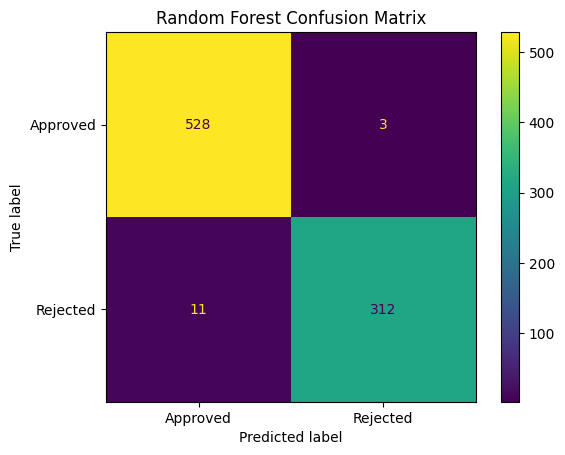

In [8]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=target_encoder.classes_)
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [9]:
predicted_labels_rf = target_encoder.inverse_transform(y_pred_rf)
actual_labels_rf = target_encoder.inverse_transform(y_test)

comparison_df_rf = pd.DataFrame({
    "Actual": actual_labels_rf,
    "Predicted": predicted_labels_rf
})

wrong_predictions_rf = comparison_df_rf[comparison_df_rf["Actual"] != comparison_df_rf["Predicted"]]
print("Number of wrong Random Forest predictions:", len(wrong_predictions_rf))
wrong_predictions_rf.head(10)

Number of wrong Random Forest predictions: 14


,Actual,Predicted
31,Rejected,Approved
49,Rejected,Approved
64,Rejected,Approved
70,Rejected,Approved
196,Approved,Rejected
354,Rejected,Approved
431,Rejected,Approved
463,Rejected,Approved
486,Approved,Rejected
515,Rejected,Approved
